In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys
from pathlib import Path

parent_dir = str(Path.cwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import pandas as pd

from pipeline import data_prep, gsea_compare as gc, plots
from viz_style import apply_style
apply_style()
nf, wr, dq, dq_cov = gc.load_sets()
dd = data_prep.load_disease_filtered()

## 1. Term-level 겹침 통계 + 질병별 diff 리스트
`Benchmark/gsea_compare/overlap_stats.csv` + `{comparison}__{which}__{pheno}.csv`

In [5]:
gc.COMPARISONS

{'norare_vs_with_rare': ('only_nbi', 'with_rare'),
 'deseq2_vs_norare': ('deseq2', 'only_nbi'),
 'deseq2_vs_withrare': ('deseq2', 'with_rare')}

In [6]:
stats, diffs = gc.compare_all(save=True)
for name in gc.COMPARISONS:
    s = stats[stats.comparison == name]
    print(f'== {name} (left={gc.COMPARISONS[name][0]} right={gc.COMPARISONS[name][1]}) ==')
    display(s[['phenotype','n_left','n_right','n_common','left_only','right_only','jaccard','sign_agree']]
            .reset_index(drop=True))

== norare_vs_with_rare (left=only_nbi right=with_rare) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),986,1068,934,52,134,0.833929,1.0
1,CAD_HF- (Ward),960,1047,929,31,118,0.861781,1.0
2,Colorectal Cancer (Chen),390,446,373,17,73,0.805616,1.0
3,Esophagus Cancer (Chen),708,804,669,39,135,0.793594,1.0
4,HIV (Chang),420,437,382,38,55,0.804211,1.0
5,HIV + Tuberculosis (Chang),407,448,384,23,64,0.815287,1.0
6,ICI-m (Raissadati),509,543,458,51,85,0.771044,1.0
7,ICI-treated Cancer (Raissadati),1278,1395,1223,55,172,0.843448,1.0
8,Liver Cancer (Chen),642,706,604,38,102,0.811828,1.0
9,Liver Cancer (Roskams-Hieter),220,360,214,6,146,0.584699,1.0


== deseq2_vs_norare (left=deseq2 right=only_nbi) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),596,986,326,270,660,0.259554,0.984663
1,CAD_HF- (Ward),559,960,303,256,657,0.249178,0.960396
2,Colorectal Cancer (Chen),160,390,57,103,333,0.115619,1.000000
3,Esophagus Cancer (Chen),127,708,46,81,662,0.058302,0.934783
4,HIV (Chang),70,420,42,28,378,0.093750,1.000000
5,HIV + Tuberculosis (Chang),437,407,204,233,203,0.318750,0.995098
6,Liver Cancer (Chen),107,642,26,81,616,0.035961,0.500000
7,Liver Cancer (Roskams-Hieter),287,220,45,242,175,0.097403,1.000000
8,Lung Cancer (Chen),319,557,187,132,370,0.271408,1.000000
9,ME_CFS (Gardella),98,149,7,91,142,0.029167,1.000000


== deseq2_vs_withrare (left=deseq2 right=with_rare) ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF+ (Ward),596,1068,327,269,741,0.244577,0.975535
1,CAD_HF- (Ward),559,1047,315,244,732,0.243997,0.946032
2,Colorectal Cancer (Chen),160,446,63,97,383,0.116022,0.968254
3,Esophagus Cancer (Chen),127,804,46,81,758,0.051977,0.934783
4,HIV (Chang),70,437,40,30,397,0.085653,1.000000
5,HIV + Tuberculosis (Chang),437,448,218,219,230,0.326837,0.995413
6,Liver Cancer (Chen),107,706,27,80,679,0.034351,0.481481
7,Liver Cancer (Roskams-Hieter),287,360,66,221,294,0.113597,0.969697
8,Lung Cancer (Chen),319,618,185,134,433,0.246011,1.000000
9,ME_CFS (Gardella),98,228,9,89,219,0.028391,1.000000


## 2. 신규(with_rare) 신호의 DB/rare 교차검증
`rare_novel_validated.csv` (term 단위) + `rare_novel_summary.csv` (질병 단위)

In [7]:
long, summary = gc.validate_rare_novel(diffs, save=True)
display(summary[['phenotype','n_new_terms','n_db_supported','n_rare_driven','n_db_and_rare','frac_db_supported']])
print('rare 유전자가 직접 lead한 신규 term (직접 근거):')
display(long[long.rare_driven][['phenotype','Term','NES','n_db','db_hits','rare_hits']]
        .sort_values('phenotype').reset_index(drop=True))

/project/cfRNA_NormativeModeling/Modeling/pipeline/gsea_compare.py:277: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'n_db_and_rare': g.apply(lambda x: (x['db_supported'] & x['rare_driven']).sum()),


,phenotype,n_new_terms,n_db_supported,n_rare_driven,n_db_and_rare,frac_db_supported
7,ICI-treated Cancer (Raissadati),172,0,3,0,0.000
9,Liver Cancer (Roskams-Hieter),146,104,4,4,0.712
3,Esophagus Cancer (Chen),135,64,6,5,0.474
0,CAD_HF+ (Ward),134,45,0,0,0.336
1,CAD_HF- (Ward),118,31,0,0,0.263
19,Tuberculosis (Chang),117,69,2,2,0.590
13,MM (Roskams-Hieter),117,69,4,1,0.590
8,Liver Cancer (Chen),102,43,3,2,0.422
10,Lung Cancer (Chen),101,55,0,0,0.545
11,ME_CFS (Gardella),91,51,4,4,0.560


rare 유전자가 직접 lead한 신규 term (직접 근거):


,phenotype,Term,NES,n_db,db_hits,rare_hits
0,Esophagus Cancer (Chen),GO_Biological_Process_2023__External Encapsula...,2.067281,1,NF1,MMP3
1,Esophagus Cancer (Chen),KEGG_2021_Human__Aldosterone-regulated sodium ...,2.066083,1,PIK3R1,INS
2,Esophagus Cancer (Chen),GO_Biological_Process_2023__Positive Regulatio...,1.903136,3,AKT1;ARNT;KDR,CCL26
3,Esophagus Cancer (Chen),GO_Biological_Process_2023__Anterograde Trans-...,1.846335,1,GRIN2A,HTR3D
4,Esophagus Cancer (Chen),GO_Biological_Process_2023__Water Transport (G...,1.815678,0,,AVP
5,Esophagus Cancer (Chen),Reactome_2022__SARS-CoV-2-host Interactions R-...,-1.608180,1,IKBKB,IFNA1
6,HIV (Chang),KEGG_2021_Human__Leukocyte transendothelial mi...,1.751159,1,RAC1,CLDN17;MYL10
7,HIV (Chang),KEGG_2021_Human__Relaxin signaling pathway,1.746084,0,,INSL5
8,HIV (Chang),Reactome_2022__Interleukin-6 Family Signaling ...,1.728519,0,,IL31
9,ICI-m (Raissadati),KEGG_2021_Human__Collecting duct acid secretion,1.825849,0,,ATP6V1G3


## 3. DESeq2의 normative DB-지지 경로 커버리지
`deseq2_coverage.csv` — 포착률·방향불일치율

In [8]:
cov = gc.deseq2_coverage(save=True)
wr_cov = cov[cov.normative == 'with_rare'].drop(columns='normative')
display(wr_cov[['phenotype','n_deseq2_sig','n_norm_sig','n_norm_db','n_db_captured','db_capture_rate','n_common','sign_disagree_rate']]
        .sort_values('db_capture_rate').reset_index(drop=True))
print('DB-지지 경로 포착률 중앙값: with_rare=%.3f  only_nbi=%.3f'
      % (wr_cov.db_capture_rate.median(), cov[cov.normative=='only_nbi'].db_capture_rate.median()))

,phenotype,n_deseq2_sig,n_norm_sig,n_norm_db,n_db_captured,db_capture_rate,n_common,sign_disagree_rate
0,Pre-eclampsia (Moufarrej),54,275,39,0,0.000,12,0.000
1,Liver Cancer (Chen),107,706,331,6,0.018,27,0.519
2,Pancreatic Cancer (Moore),130,607,290,9,0.031,65,0.738
3,Esophagus Cancer (Chen),127,804,328,14,0.043,46,0.065
4,ME_CFS (Gardella),98,228,129,7,0.054,9,0.000
5,Pancreatitis (Moore),50,298,118,8,0.068,22,0.955
6,Colorectal Cancer (Chen),160,446,177,14,0.079,63,0.032
7,HIV (Chang),70,437,230,35,0.152,40,0.000
8,Liver Cancer (Roskams-Hieter),287,360,257,52,0.202,66,0.030
9,CAD_HF+ (Ward),596,1068,280,57,0.204,327,0.024


DB-지지 경로 포착률 중앙값: with_rare=0.203  only_nbi=0.187


## 4. 대칭 DB-hit 비교 (DESeq2 vs Normative)
섹션 3의 `deseq2_coverage`는 DB-지지를 normative 항목에서만 정의한 뒤 DESeq2 포착률을 보는 비대칭 관점이다. 여기서는 세 방법(deseq2 / no_filter / with_rare)을 **동일 규칙**(자기 유의 term의 lead gene ∩ Open Targets 참조)으로 채점해 DB-hit **개수**와 비율을 대칭적으로 비교한다. 개수(절대 커버리지)가 비율(정밀도)보다 중요할 수 있으므로 둘 다 표시한다.
`Benchmark/gsea_compare/db_hit_rates.csv` + `_summary.csv`, `Benchmark/Figures/db_hit_rates.png`

== pooled over phenotypes with an Open Targets reference ==


,method,n_pheno,total_sig,total_db,mean_db_hit_rate,pooled_db_hit_rate
0,deseq2,18,4566,2220,0.453,0.486
1,deseq2_cov,18,1963,1143,0.437,0.582
2,only_nbi,19,8820,3802,0.440,0.431
3,with_rare,19,9990,4398,0.448,0.440



== per-phenotype DB-hit counts (n_db) ==


method,deseq2,deseq2_cov,with_rare
phenotype,,,
CAD_HF+ (Ward),183.0,1.0,280.0
CAD_HF- (Ward),167.0,1.0,278.0
Colorectal Cancer (Chen),95.0,14.0,177.0
Esophagus Cancer (Chen),77.0,3.0,328.0
HIV (Chang),51.0,54.0,230.0
HIV + Tuberculosis (Chang),322.0,178.0,266.0
ICI-m (Raissadati),NaN,NaN,280.0
Liver Cancer (Chen),52.0,38.0,331.0
Liver Cancer (Roskams-Hieter),194.0,24.0,257.0


== per-phenotype DB-hit rate (n_db / n_sig) ==


method,deseq2,deseq2_cov,with_rare
phenotype,,,
CAD_HF+ (Ward),0.307,0.091,0.262
CAD_HF- (Ward),0.299,0.500,0.266
Colorectal Cancer (Chen),0.594,0.700,0.397
Esophagus Cancer (Chen),0.606,0.600,0.408
HIV (Chang),0.729,0.486,0.526
HIV + Tuberculosis (Chang),0.737,0.616,0.594
ICI-m (Raissadati),NaN,NaN,0.516
Liver Cancer (Chen),0.486,0.623,0.469
Liver Cancer (Roskams-Hieter),0.676,0.324,0.714


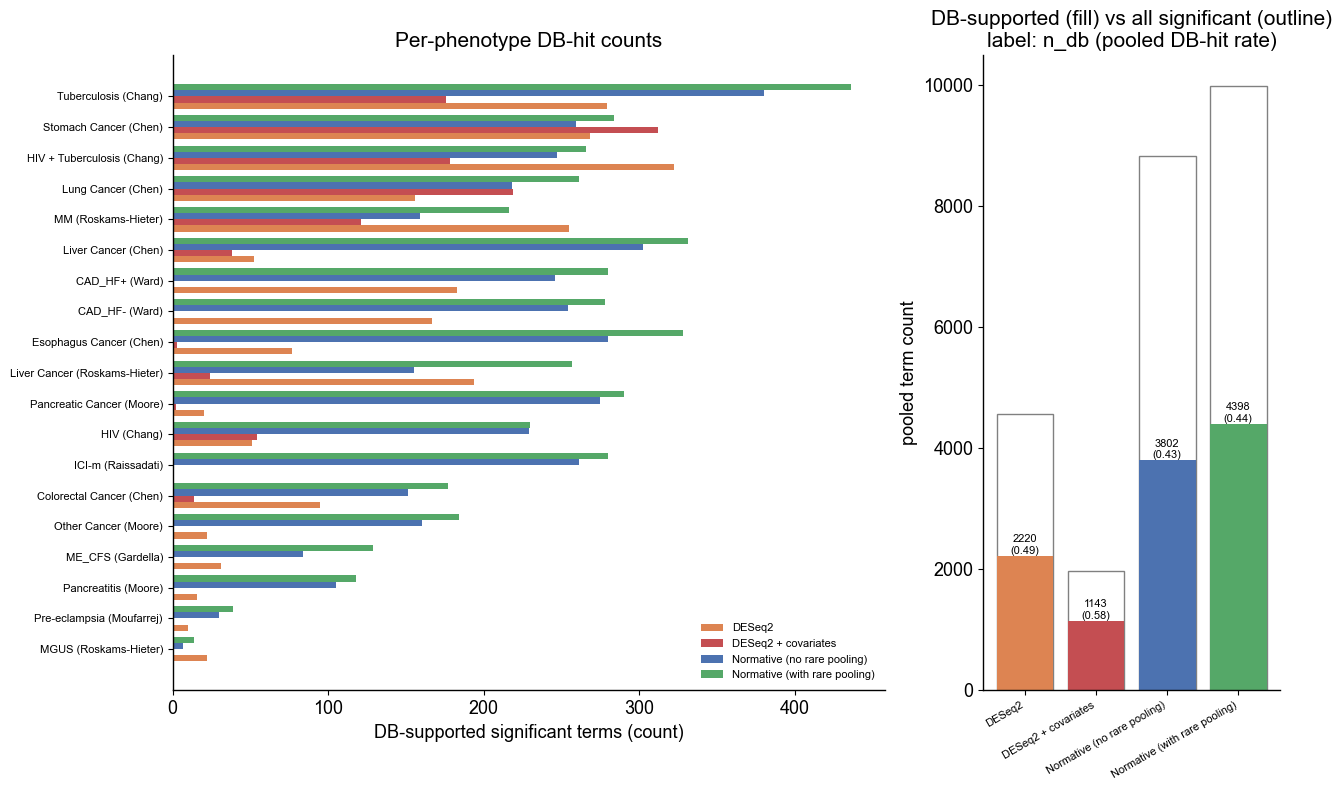

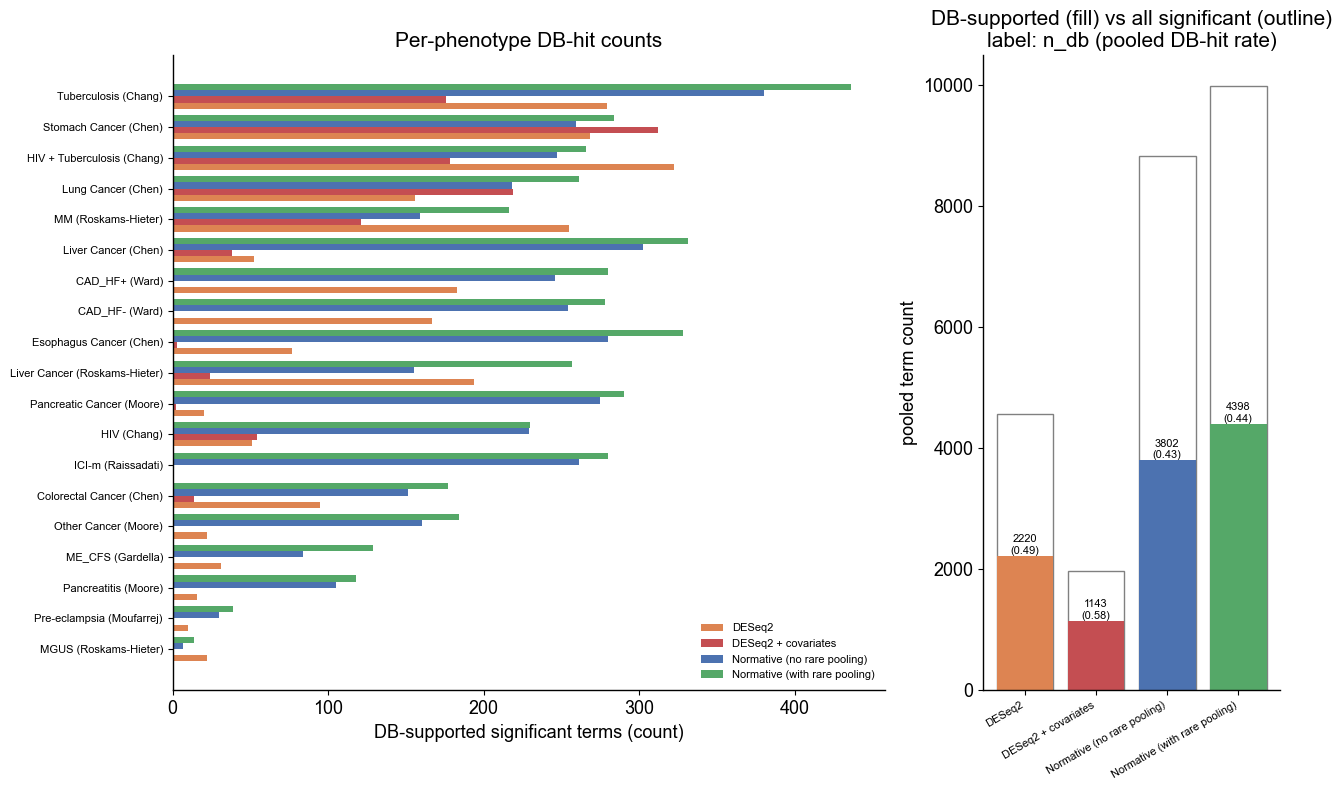

In [9]:
rates, db_summary = gc.db_hit_rates(save=True)
print('== pooled over phenotypes with an Open Targets reference ==')
display(db_summary)
methods_avail = [m for m in ['deseq2', 'deseq2_cov', 'no_filter', 'with_rare']
                 if m in rates['method'].unique()]
sub = rates[rates.has_ot_ref]
print('\n== per-phenotype DB-hit counts (n_db) ==')
display(sub.pivot(index='phenotype', columns='method', values='n_db')[methods_avail])
print('== per-phenotype DB-hit rate (n_db / n_sig) ==')
display(sub.pivot(index='phenotype', columns='method', values='db_hit_rate')[methods_avail])
plots.plot_db_hit_rates(rates, db_summary, save=True)

## 5. DESeq2 공변량 보정 vs 미보정 GSEA 비교
`run_deseq2_covariate.py` 산출물 (`Benchmark/deseq2_covariate_gsea/`): 10개 BIAS_COLUMNS를 전체 샘플 StandardScaler로 표준화한 뒤 design `~cov1+...+cov10+condition`으로 보정한 버전.
- `deseq2_cov_vs_nocov_overlap.csv`: term-level Jaccard + sign_agree (공변량 보정 전후 변화 정도)
- `deseq2_cov_db_hits.csv`: deseq2_cov만의 단독 DB-hit (섹션 4 요약에는 이미 통합됨)

In [10]:
ov_cov, db_cov = gc.deseq2_cov_vs_nocov(save=True)
print('== DESeq2 공변량 보정 전후 term-level 겹침 ==')
display(ov_cov[['phenotype','n_left','n_right','n_common','left_only','right_only','jaccard','sign_agree']]
        .sort_values('jaccard').reset_index(drop=True))
print('\nJaccard 중앙값:', round(ov_cov.jaccard.median(), 3),
      '  sign_agree 중앙값:', round(ov_cov.sign_agree.median(), 3))
print('\n== deseq2_cov DB-hit (per phenotype) ==')
display(db_cov[['phenotype','n_sig','n_db','db_hit_rate']].sort_values('n_db', ascending=False).reset_index(drop=True))

== DESeq2 공변량 보정 전후 term-level 겹침 ==


,phenotype,n_left,n_right,n_common,left_only,right_only,jaccard,sign_agree
0,CAD_HF- (Ward),559,2,0,559,2,0.000000,NaN
1,Pancreatitis (Moore),50,0,0,50,0,0.000000,NaN
2,MGUS (Roskams-Hieter),188,0,0,188,0,0.000000,NaN
3,ME_CFS (Gardella),98,1,0,98,1,0.000000,NaN
4,Other Cancer (Moore),72,0,0,72,0,0.000000,NaN
5,Esophagus Cancer (Chen),127,5,1,126,4,0.007634,1.000000
6,CAD_HF+ (Ward),596,11,9,587,2,0.015050,0.111111
7,Pre-eclampsia (Moufarrej),54,2,1,53,1,0.018182,1.000000
8,Colorectal Cancer (Chen),160,20,7,153,13,0.040462,1.000000
9,Liver Cancer (Chen),107,61,10,97,51,0.063291,1.000000



Jaccard 중앙값: 0.052   sign_agree 중앙값: 1.0

== deseq2_cov DB-hit (per phenotype) ==


,phenotype,n_sig,n_db,db_hit_rate
0,Stomach Cancer (Chen),541,312,0.577
1,Lung Cancer (Chen),388,219,0.564
2,HIV + Tuberculosis (Chang),289,178,0.616
3,Tuberculosis (Chang),209,176,0.842
4,MM (Roskams-Hieter),228,121,0.531
5,HIV (Chang),111,54,0.486
6,Liver Cancer (Chen),61,38,0.623
7,Liver Cancer (Roskams-Hieter),74,24,0.324
8,Colorectal Cancer (Chen),20,14,0.700
9,Esophagus Cancer (Chen),5,3,0.600


## 6. Gene-level Hit Overlap — Venn (DESeq2 no-cov | DESeq2 w/cov | Normative Model)
유전자 단위 유의 hit 집합의 포함관계. DESeq2는 padj<0.05, Normative는 |z|≥z_flag인 샘플이 하나 이상 존재하는 유전자.
ICI-m/ICI-treated처럼 DESeq2 결과가 없는 phenotype은 자동 제외.
`Benchmark/Figures/venn_benchmarks.png`

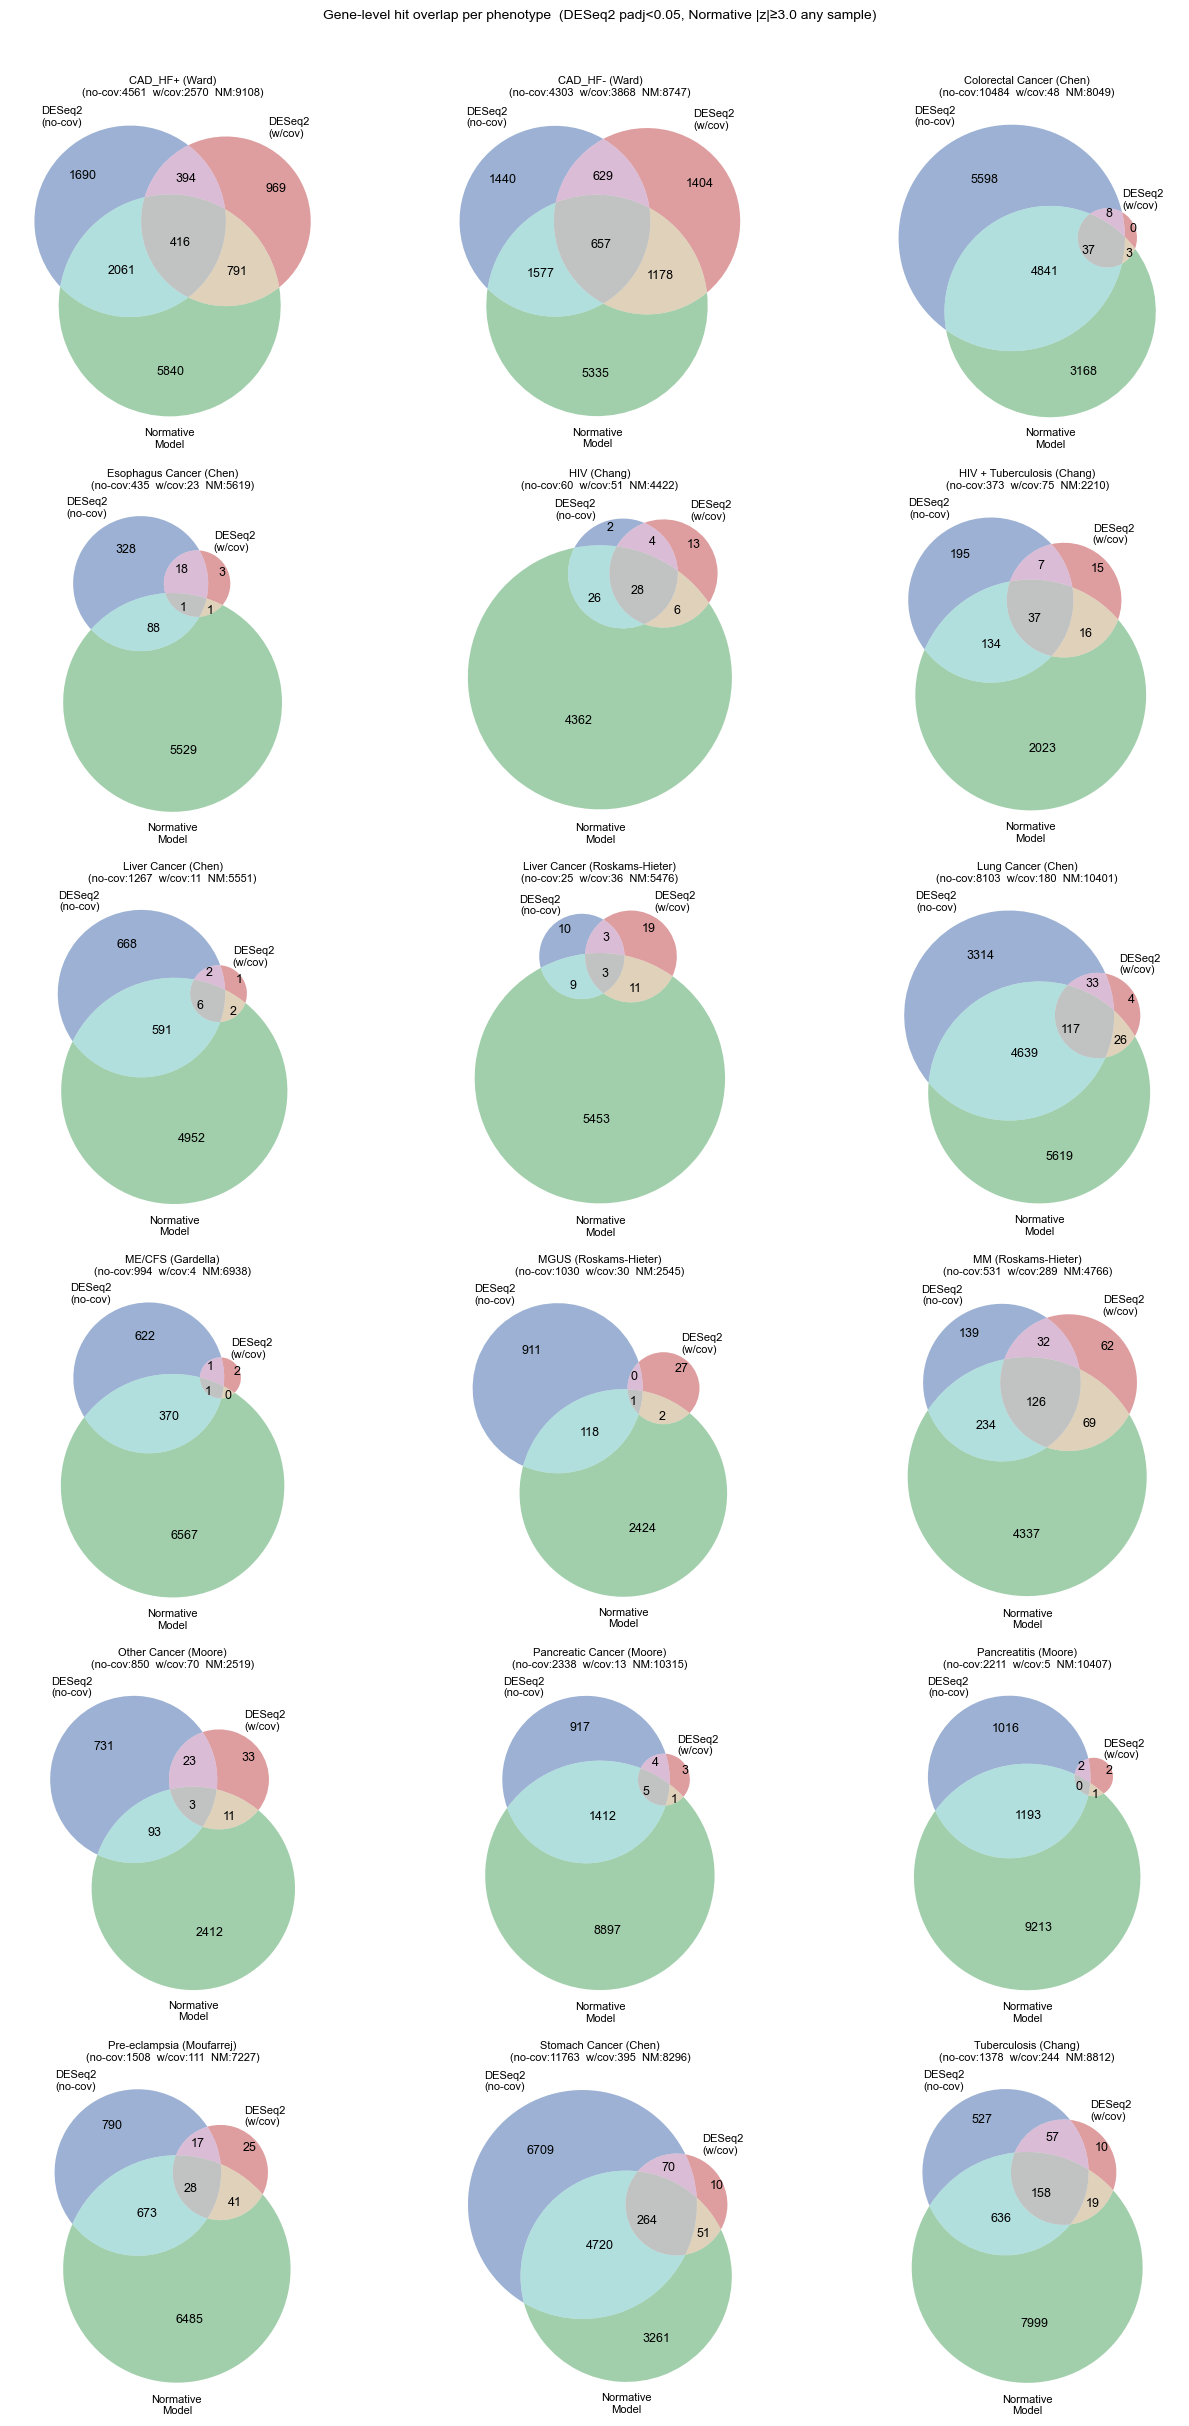

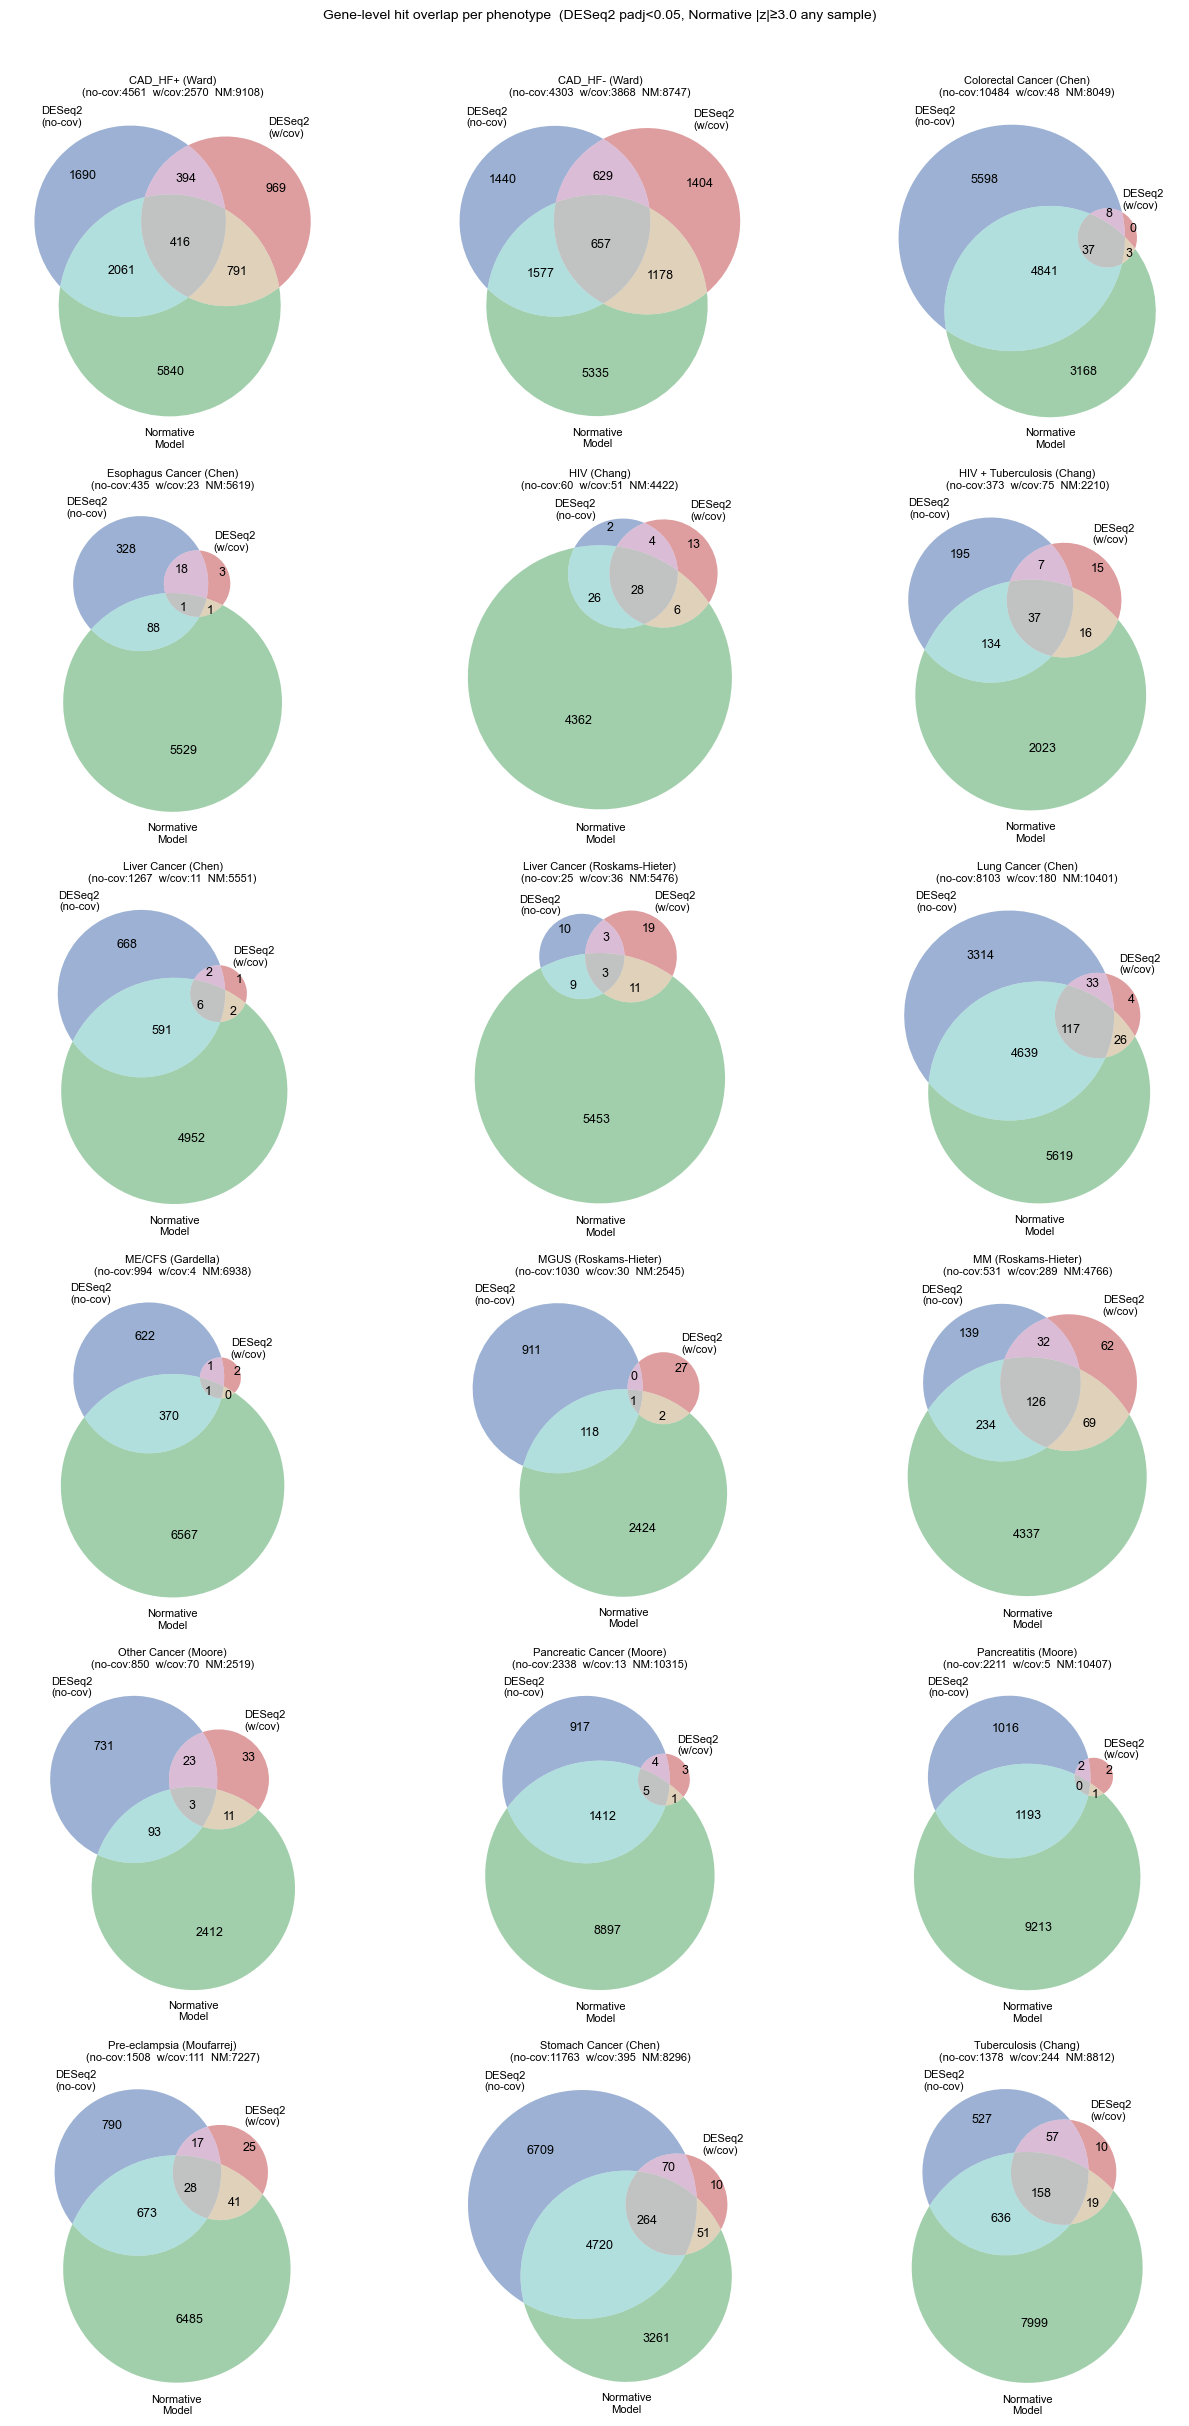

In [11]:
plots.plot_venn_benchmarks(dd, padj_thr=0.05, ncols=3)

## 7. GSEA Pathway Overlap — Venn (DESeq2 no-cov | DESeq2 w/cov | NM with_rare)
FDR<0.05 유의 pathway 집합의 포함관계. 원 넓이는 sqrt 스케일, 숫자는 실제 term 수.
gene-level Venn과 동일한 palette (파란=no-cov, 빨간=w/cov, 초록=NM).
DESeq2 결과가 없는 phenotype(ICI 계열)은 자동 제외.
`Benchmark/Figures/venn_gsea_pathways.png`

In [12]:
wr

{'CAD_HF+ (Ward)':          Name                                               Term        ES  \
 0     prerank  Reactome_2022__Voltage Gated Potassium Channel...  0.614478   
 1     prerank  Reactome_2022__Receptor-type Tyrosine-Protein ...  0.627734   
 2     prerank  GO_Biological_Process_2023__Positive Regulatio...  0.831045   
 3     prerank  Reactome_2022__Collagen Chain Trimerization R-...  0.583697   
 4     prerank  GO_Biological_Process_2023__Positive Regulatio...  0.641780   
 ...       ...                                                ...       ...   
 1063  prerank  GO_Biological_Process_2023__Intrinsic Apoptoti... -0.595105   
 1064  prerank  GO_Biological_Process_2023__Positive Regulatio... -0.706407   
 1065  prerank  GO_Biological_Process_2023__Cellular Response ... -0.621622   
 1066  prerank  GO_Biological_Process_2023__Porphyrin-Containi... -0.642319   
 1067  prerank  Reactome_2022__Neutrophil Degranulation R-HSA-... -0.532567   
 
            NES  NOM p-val  FDR 

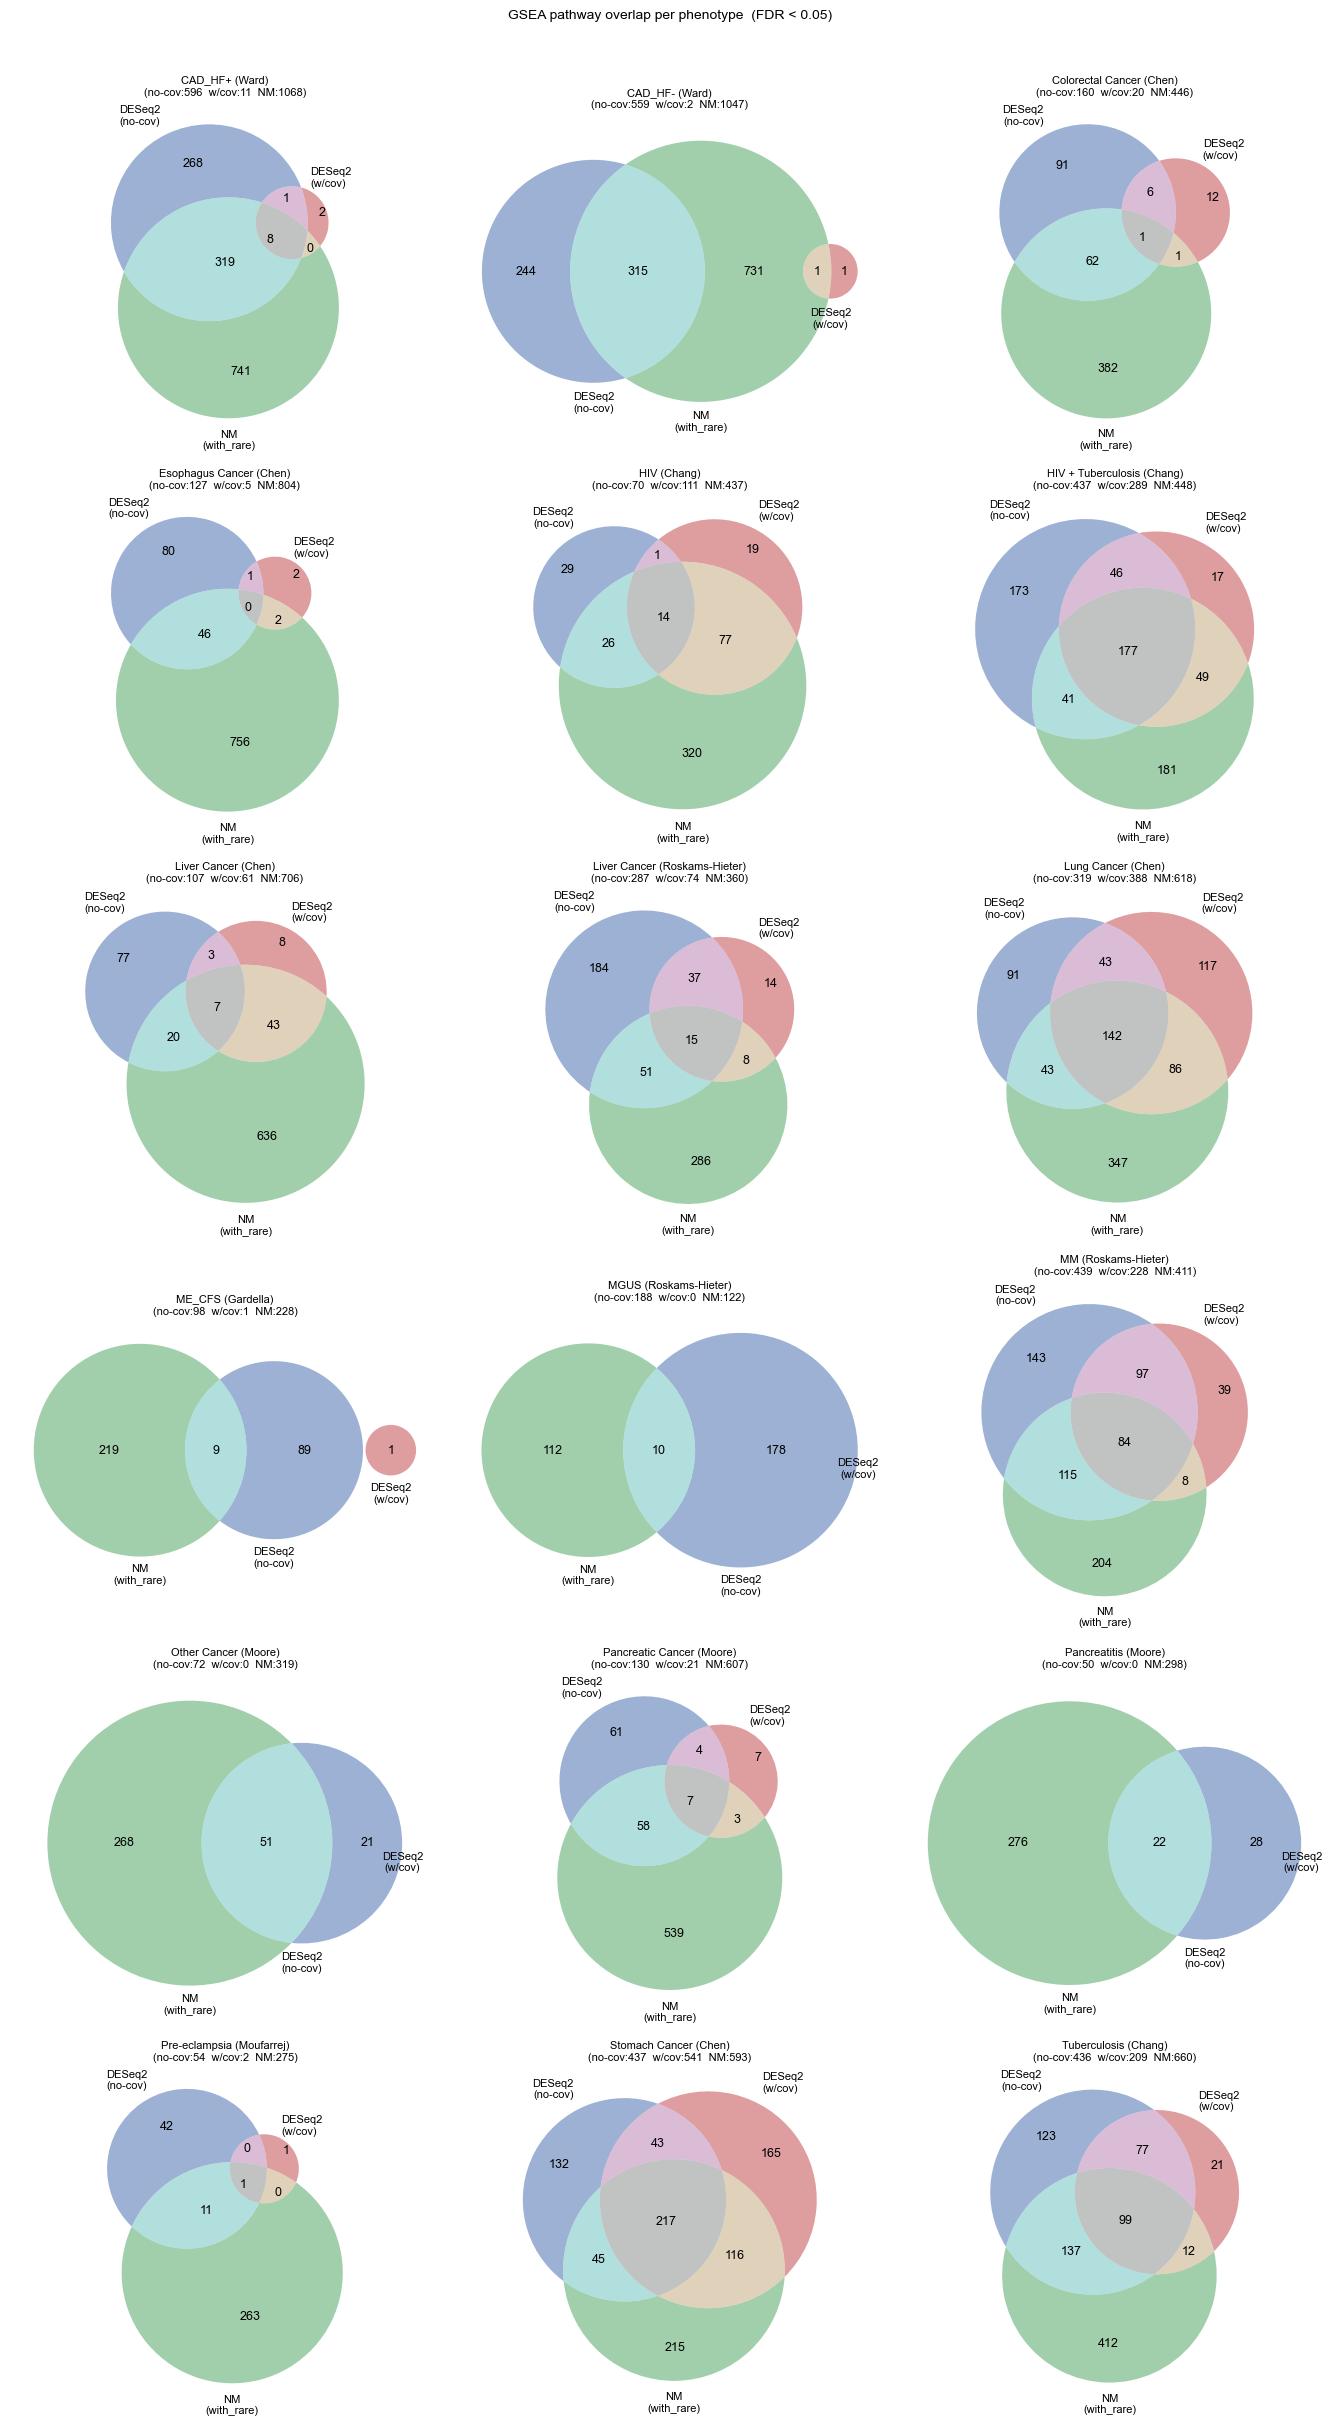

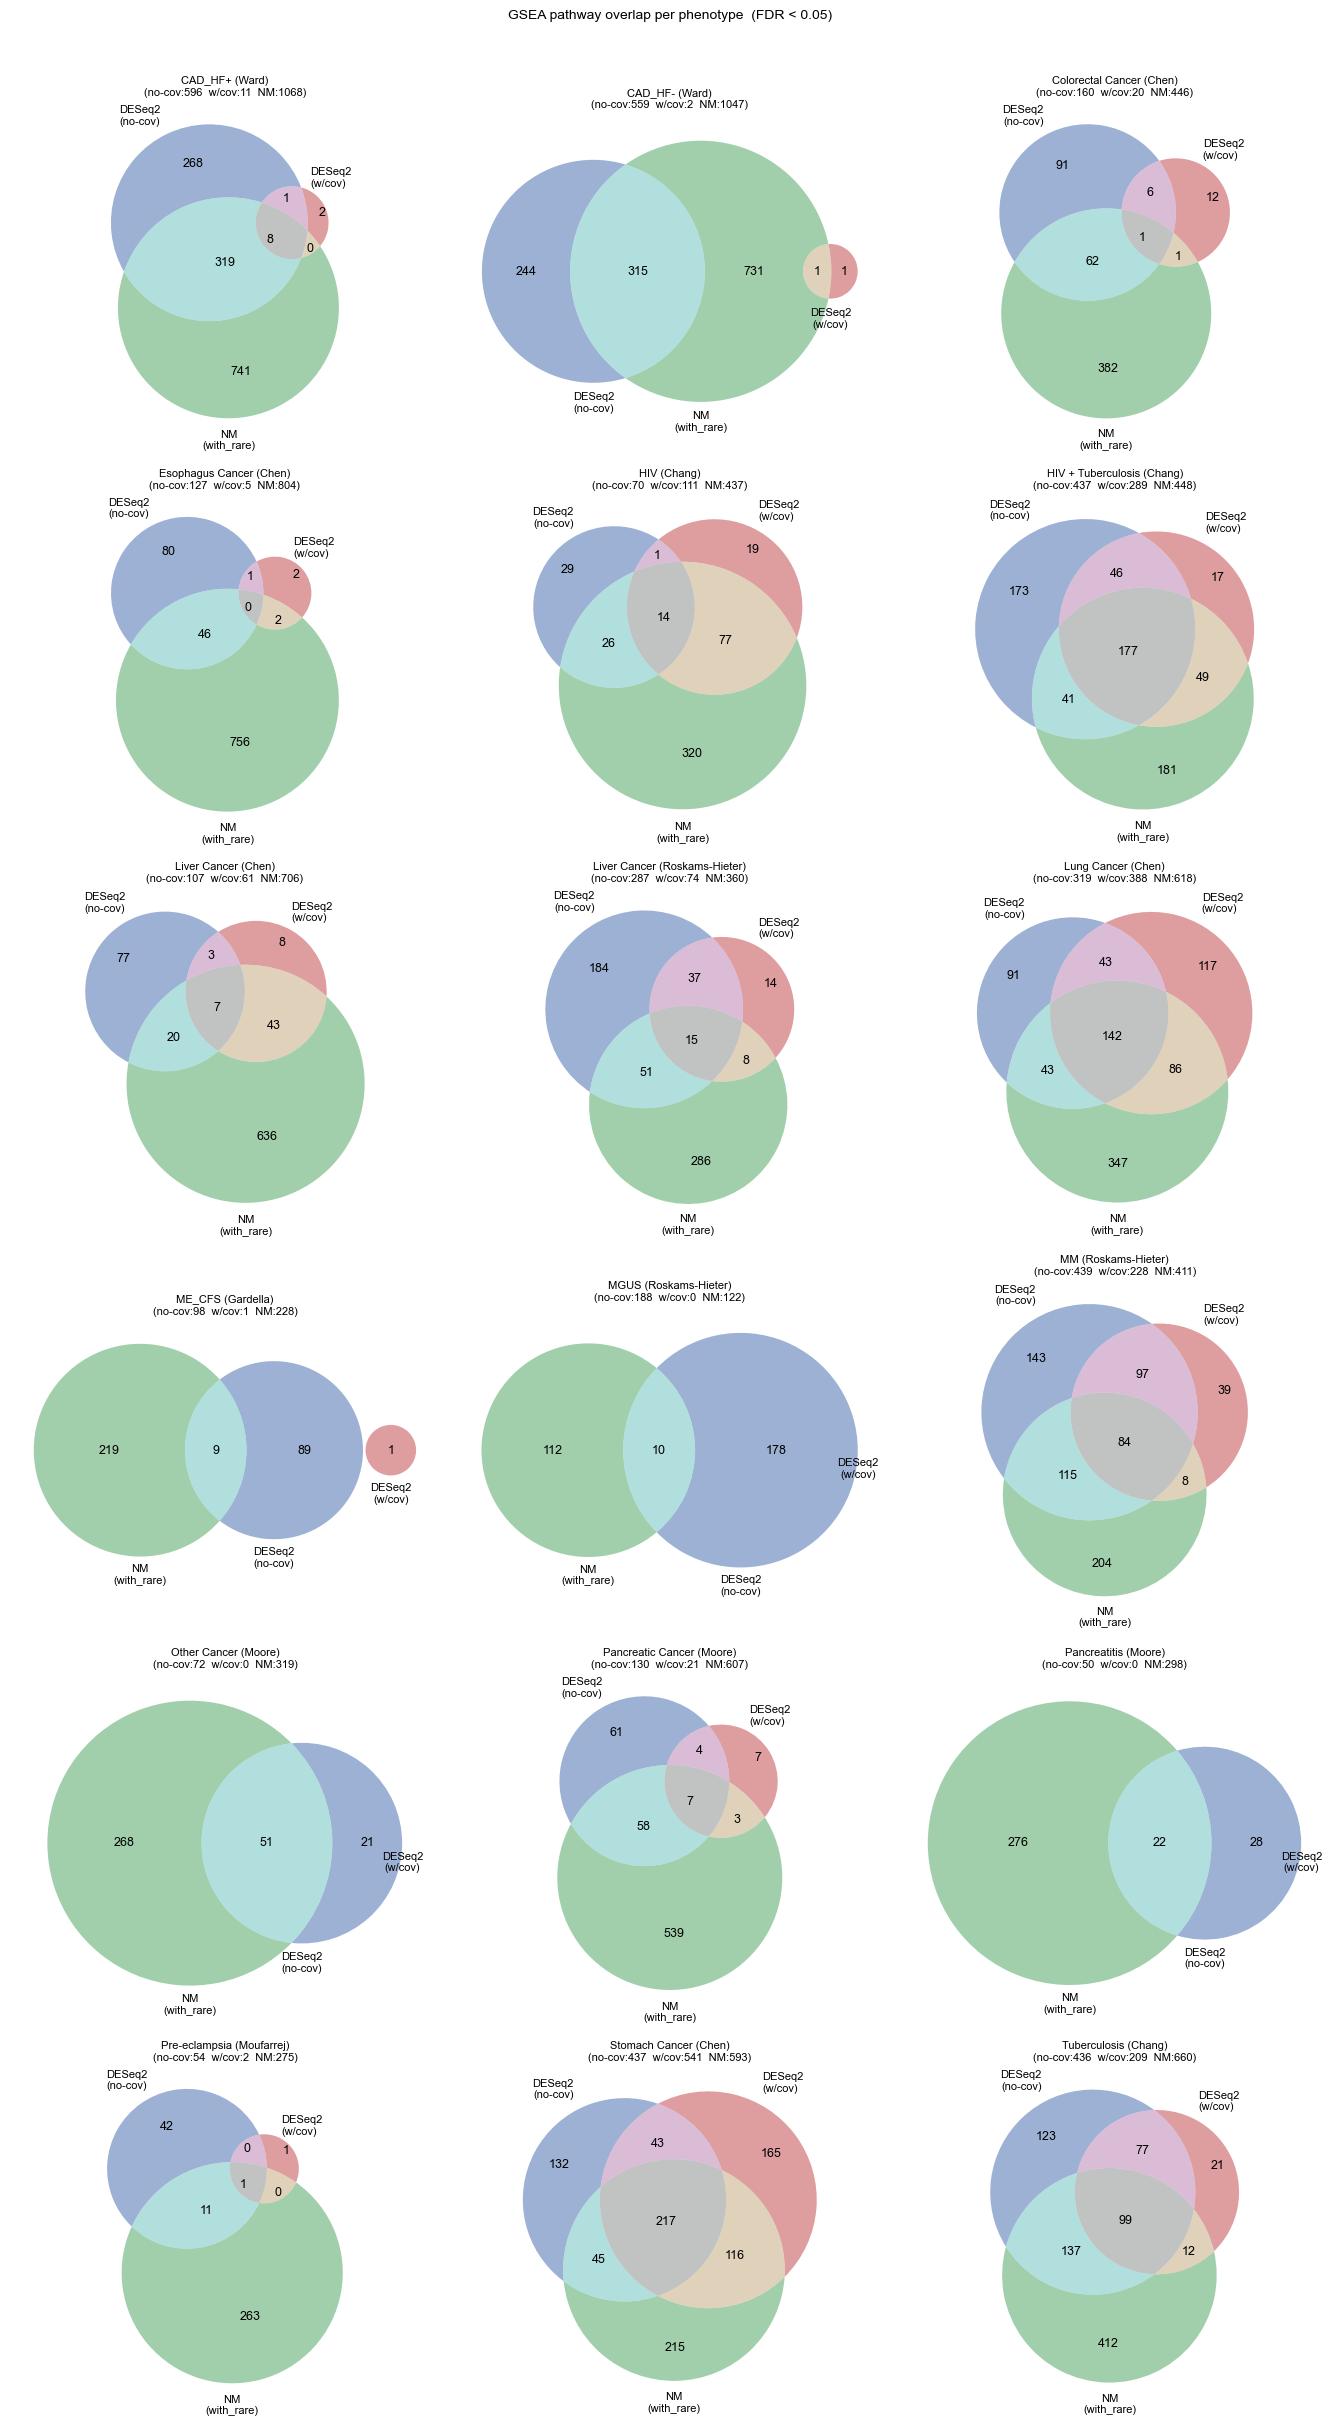

In [13]:
plots.plot_venn_gsea_pathways(wr, dq, dq_cov, ncols=3, save=True)